In [9]:
import pandas as pd 
import numpy as np

In [7]:
df = pd.read_parquet("../data/processed/pfas_acs_zcta_month.parquet")

In [10]:
contain_pfas = df[df['any_detection'] == True] 
contain_pfas

,zcta,month,mean_result_ngL,n_records,n_detections,n_systems,n_contaminants,pws_names,state,any_detection,...,renter_occupied,pct_below_poverty,pct_white_nh,pct_black_nh,pct_asian_nh,pct_amerind_nh,pct_hispanic,pct_nonwhite,pct_renter,city
7,00612,2025-01-01,6.466667,319,3,1,29,ARECIBO URBANO,PR,True,...,9103.0,40.837773,0.397041,0.081650,0.012808,0.000000,99.282764,99.602959,38.838638,Arecibo
13,00637,2024-07-01,5.700000,58,1,1,29,"SABANA GRANDE, PR",PR,True,...,1801.0,44.548847,0.843384,0.000000,0.043699,0.000000,99.034260,99.156616,23.838518,Sabana Grande
18,00638,2023-07-01,6.525000,29,4,1,29,CIDRA URBANO,PR,True,...,1724.0,57.824109,0.419299,0.000000,0.000000,0.000000,99.580701,99.580701,29.101958,Ciales
19,00638,2023-10-01,5.266667,29,3,1,29,CIDRA URBANO,PR,True,...,1724.0,57.824109,0.419299,0.000000,0.000000,0.000000,99.580701,99.580701,29.101958,Ciales
20,00638,2024-01-01,7.000000,29,1,1,29,CIDRA URBANO,PR,True,...,1724.0,57.824109,0.419299,0.000000,0.000000,0.000000,99.580701,99.580701,29.101958,Ciales
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100653,99775,2024-07-01,5.787500,54,8,2,29,COLLEGE UTILITIES CORPORATION; GOLDEN HEART UT...,AK,True,...,136.0,0.000000,43.281471,6.364922,26.025460,3.960396,7.072136,56.718529,100.000000,Fairbanks
100654,99775,2024-12-01,4.050000,29,2,1,29,COLLEGE UTILITIES CORPORATION,AK,True,...,136.0,0.000000,43.281471,6.364922,26.025460,3.960396,7.072136,56.718529,100.000000,Fairbanks
100655,99775,2025-01-01,5.000000,29,1,1,29,GOLDEN HEART UTILITIES,AK,True,...,136.0,0.000000,43.281471,6.364922,26.025460,3.960396,7.072136,56.718529,100.000000,Fairbanks
100658,99790,2024-07-01,5.300000,29,4,1,29,GOLDEN HEART UTILITIES,AK,True,...,0.0,100.000000,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,Fairbanks


In [22]:
#zcta/cities with the most average PFAS contamination
contain_pfas.groupby(['zcta', 'city'])[['mean_result_ngL']].mean().sort_values(by='mean_result_ngL', ascending=False).head(10)

,,mean_result_ngL
zcta,city,
55071,Saint Paul Park,1225.000000
44118,Cleveland,400.000000
55128,Saint Paul,285.990556
96950,Saipan,257.999126
85258,Scottsdale,171.150000
98027,Issaquah,170.130000
56601,Bemidji,160.000000
52736,Unknown city,137.710000
85718,Tucson,134.700000


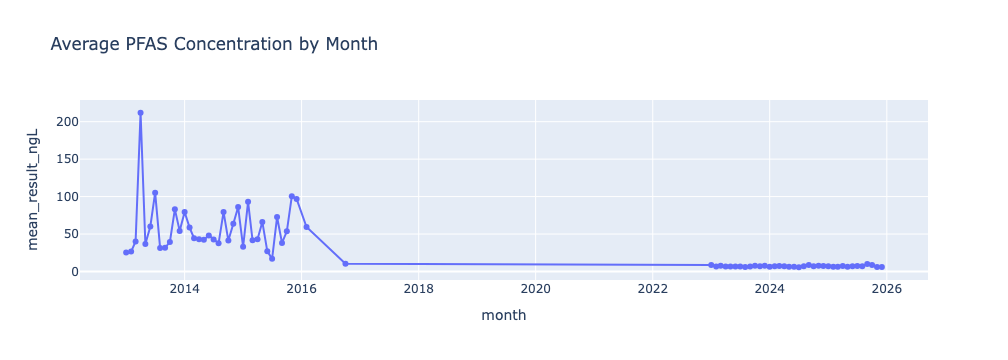

In [12]:
#timeline of PFAS contamination (U.S.)
import plotly.express as px

contain_pfas_grouped = (
    contain_pfas
    .groupby("month")["mean_result_ngL"]
    .mean()
    .reset_index()
)

fig = px.line(
    contain_pfas_grouped,
    x="month",
    y="mean_result_ngL",
    markers=True,
    title="Average PFAS Concentration by Month"
)

fig.show()

In [27]:
#grouping by zcta codes and averaging demographic information 
zcta_pfas_with_demog = contain_pfas.groupby('zcta').agg({'mean_result_ngL': 'mean', 
                                  'n_detections': 'sum', 
                                  'n_contaminants': 'max', #only test for a max of 29 contaminants 
                                  'renter_occupied': 'mean',
                                  'pct_below_poverty': 'mean',
                                  'pct_white_nh': 'mean', 
                                  'pct_black_nh': 'mean', 
                                  'pct_asian_nh': 'mean',
                                  'pct_amerind_nh':'mean',
                                  'pct_hispanic': 'mean',
                                  'pct_nonwhite': 'mean',
                                  'pct_renter': 'mean',
                                  'city': 'first'}).sort_values(by='mean_result_ngL', ascending = False)
zcta_pfas_with_demog

,mean_result_ngL,n_detections,n_contaminants,renter_occupied,pct_below_poverty,pct_white_nh,pct_black_nh,pct_asian_nh,pct_amerind_nh,pct_hispanic,pct_nonwhite,pct_renter,city
zcta,,,,,,,,,,,,,
55071,1225.000000,2,29,477.0,5.270410,77.509902,2.548648,5.579473,0.000000,11.520579,22.490098,20.428266,Saint Paul Park
44118,400.000000,1,6,6312.0,15.683206,57.107133,33.392755,3.117185,0.079229,2.059967,42.892867,38.783410,Cleveland
55128,285.990556,26,29,2608.0,6.249566,66.619451,8.319226,12.855415,0.310935,6.128865,33.380549,22.017729,Saint Paul
96950,257.999126,55,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Saipan
85258,171.150000,9,29,3359.0,10.801147,84.622316,2.691584,3.667137,0.082276,6.170663,15.377684,26.246288,Scottsdale
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21213,3.000000,1,29,5414.0,24.581831,5.939529,86.273807,0.218787,0.272587,4.472580,94.060471,46.821759,Baltimore
30917,3.000000,1,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Unknown city
86404,3.000000,1,29,1562.0,13.284741,82.561221,0.174918,0.800382,0.376338,12.482773,17.438779,17.568328,Lake Havasu City


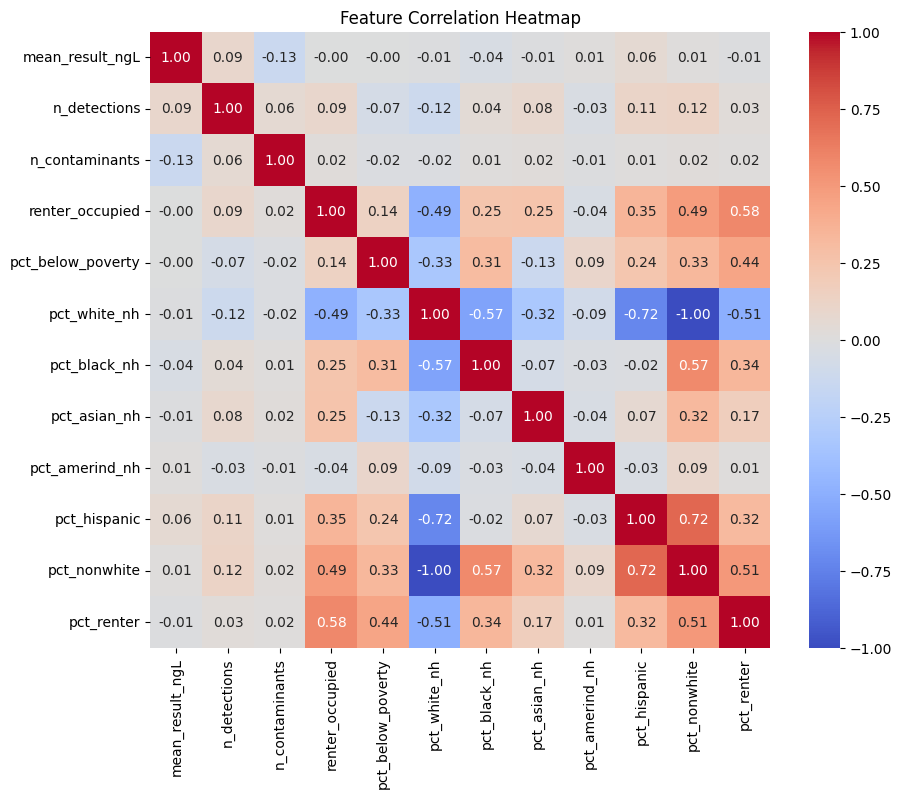

In [37]:
import seaborn as sns 
import matplotlib.pyplot as plt

corr_matrix = zcta_pfas_with_demog.drop('city', axis=1).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()